In [ ]:
pip install keras tensorflow

In [ ]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation='sigmoid')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI and ML/Workshop_5/Copy of FruitinAmazon.zip"
extract_path = "/content/drive/MyDrive/AI and ML/Workshop_5/FruitinAmazon"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset unzipped successfully!")

✅ Dataset unzipped successfully!


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
from PIL import Image

# Paths to dataset
train_dir = "/content/drive/MyDrive/AI and ML/Workshop_5/FruitinAmazon/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI and ML/Workshop_5/FruitinAmazon/FruitinAmazon/test"

# Image size
IMG_HEIGHT = 64
IMG_WIDTH = 64

# Function to load images
def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    print(f"Classes in {folder}:", class_map)

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        if not os.path.isdir(class_path):
            continue

        for filename in os.listdir(class_path):
            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            img_path = os.path.join(class_path, filename)

            try:
                img = Image.open(img_path).convert("RGB")
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))
                img = np.array(img) / 255.0

                images.append(img)
                labels.append(label)

            except Exception as e:
                print(f"Skipping: {img_path}")

    return np.array(images), np.array(labels), class_names


# LOAD DATA (like MNIST but from Drive)
x_train, y_train, class_names = load_images_from_folder(train_dir)
x_test, y_test, _ = load_images_from_folder(test_dir)

# Define CNN model (same style, just input shape updated)
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")
])

# Compile
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train
model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test, y_test)
)

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# Predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted labels:", predicted_labels)
print("Actual labels:", y_test[:5])

Classes in /content/drive/MyDrive/AI and ML/Workshop_5/FruitinAmazon/FruitinAmazon/train: {'acai': 0, 'cupuacu': 1, 'graviola': 2, 'guarana': 3, 'pupunha': 4, 'tucuma': 5}
Classes in /content/drive/MyDrive/AI and ML/Workshop_5/FruitinAmazon/FruitinAmazon/test: {'acai': 0, 'cupuacu': 1, 'graviola': 2, 'guarana': 3, 'pupunha': 4, 'tucuma': 5}
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 273ms/step - accuracy: 0.1333 - loss: 1.9215 - val_accuracy: 0.2333 - val_loss: 1.7531
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.4000 - loss: 1.6516 - val_accuracy: 0.3333 - val_loss: 1.5231
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - accuracy: 0.3111 - loss: 1.4767 - val_accuracy: 0.3333 - val_loss: 1.3680
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - accuracy: 0.5667 - loss: 1.2340 - val_accuracy: 0.5000 - val_loss: 1.3084
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - accuracy: 0.7222 - loss: 1.0563 - val_accuracy: 0.6667 - val_loss: 1.1295
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms

Input Layer


In [ ]:
input_shape=(28,28,1)

First Convolution Layer

In [ ]:
layers.Conv2D(32,(3,3),activation="relu",input_shape=(28,28,1)),

(<Conv2D name=conv2d_4, built=False>,)

First Pooling layer

In [ ]:
layers.MaxPooling2D((2, 2)),

(<MaxPooling2D name=max_pooling2d_4, built=True>,)

Second Convolutional Layer:

In [ ]:
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),

(<Conv2D name=conv2d_5, built=False>,)

Second Pooling Layer:

In [ ]:
layers.MaxPooling2D((2, 2)),

(<MaxPooling2D name=max_pooling2d_5, built=True>,)

Flatten Layer:

In [ ]:
layers.Flatten(),

(<Flatten name=flatten_2, built=False>,)

Fully Connected Dense Layer:

In [ ]:
layers.Dense(128, activation="relu"),

(<Dense name=dense_5, built=False>,)

Output Layer:

In [ ]:
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits

<Dense name=dense_6, built=False>

Display one image per class

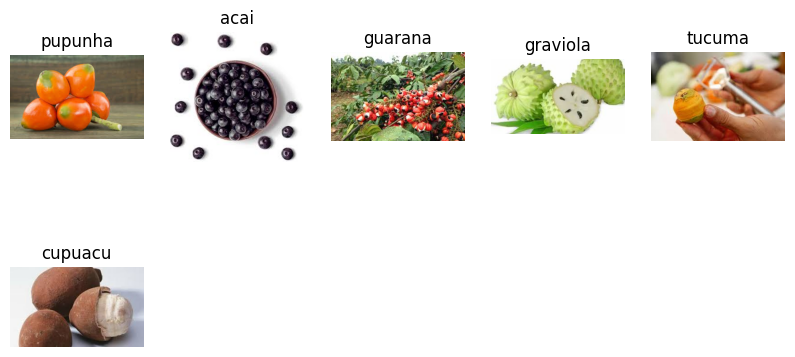

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/AI and ML/Workshop_5/FruitinAmazon/FruitinAmazon/train"

class_names = os.listdir(train_dir)

plt.figure(figsize=(10, 5))

for i, class_name in enumerate(class_names[:10]):  # first 10 classes
    class_path = os.path.join(train_dir, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()



* Loads one random image from each class folder.
* Displays them in a grid (2 rows).
* Helps understand dataset diversity and class differences.






Check & Remove Corrupted Images

In [ ]:
from PIL import Image

corrupted = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    for file in os.listdir(class_path):
        img_path = os.path.join(class_path, file)

        try:
            img = Image.open(img_path)
            img.verify()  # verify image
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


## Load Dataset using Keras

In [ ]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Loads images directly from folders.
Splits into training (80%) and validation (20%).
Normalizes pixel values to improve training performance.

## CNN Model Implementation

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

num_classes = len(os.listdir(train_dir))

model = keras.Sequential([
    layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),

    layers.Dense(num_classes, activation="softmax")
])

Uses convolution layers to extract features.
Pooling reduces image size and computation.
Dense layers learn classification patterns.

## Compile + Train Model

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)
earlystop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,   # (you can set 250 as per sheet, but 50 is practical)
    batch_size=16,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.1250 - loss: 1.8777

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 900ms/step - accuracy: 0.1250 - loss: 1.9130 - val_accuracy: 0.2222 - val_loss: 1.9174
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.3594 - loss: 1.7319

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 515ms/step - accuracy: 0.3750 - loss: 1.7073 - val_accuracy: 0.2222 - val_loss: 1.8899
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.3090 - loss: 1.5963

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 456ms/step - accuracy: 0.3333 - loss: 1.5466 - val_accuracy: 0.2222 - val_loss: 1.8445
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 417ms/step - accuracy: 0.4306 - loss: 1.3551 - val_accuracy: 0.2222 - val_loss: 1.8580
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 416ms/step - accuracy: 0.5000 - loss: 1.1259 - val_accuracy: 0.2222 - val_loss: 1.8917
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 534ms/step - accuracy: 0.6250 - loss: 0.9269 - val_accuracy: 0.2222 - val_loss: 1.9382
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 755ms/step - accuracy: 0.8194 - loss: 0.6681 - val_accuracy: 0.2222 - val_loss: 1.9457
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 538ms/step - accuracy: 0.8611 - loss: 0.4784 - val_accuracy: 0.2778 - val_loss: 2.0355
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 493ms/step - accuracy: 0.9306 - loss: 0.3183 - val_accuracy: 0.3333 - val_loss: 1.8870
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.9797 - loss: 0.1841

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 450ms/step - accuracy: 0.9861 - loss: 0.1747 - val_accuracy: 0.3889 - val_loss: 1.6955
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 409ms/step - accuracy: 0.9861 - loss: 0.0985 - val_accuracy: 0.2778 - val_loss: 3.0422
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 422ms/step - accuracy: 0.9861 - loss: 0.1173 - val_accuracy: 0.2222 - val_loss: 3.0549
Epoch 13/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 437ms/step - accuracy: 1.0000 - loss: 0.0435 - val_accuracy: 0.2222 - val_loss: 2.3304
Epoch 14/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 494ms/step - accuracy: 1.0000 - loss: 0.0197 - val_accuracy: 0.3889 - val_loss: 1.9862
Epoch 15/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 660ms/step - accuracy: 1.0000 - loss: 0.0189 - val_accuracy: 0.4444 - val_loss: 2.2861
Epoch 16/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 409ms/step - accuracy: 1.0000 - loss: 0.0139 - val_accuracy: 0.3333 - val_loss: 2.9668
Epoch 17/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 498ms/step - accuracy: 1.0000 - loss: 0.0071 - val_accuracy: 0.2778 - val_loss: 3.5

Compiles model with optimizer and loss function.
Uses callbacks to save best model and stop overfitting.
Trains model on dataset.

## Evaluate Model

In [ ]:
test_dir = "/content/drive/MyDrive/AI and ML/Workshop_5/FruitinAmazon/FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128,128),
    batch_size=32
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

loss, acc = model.evaluate(test_ds)
print(f"Test Accuracy: {acc:.4f}")

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 652ms/step - accuracy: 0.7000 - loss: 1.0463
Test Accuracy: 0.7000


Loads test dataset separately.
Evaluates model performance on unseen data.
Gives final accuracy.

## Save & Load Model

In [ ]:
# Save
model.save("fruit_model.h5")

# Load
loaded_model = keras.models.load_model("fruit_model.h5")

# Evaluate again
loss, acc = loaded_model.evaluate(test_ds)
print("Loaded Model Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step - accuracy: 0.7000 - loss: 1.0463
Loaded Model Accuracy: 0.699999988079071


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,349,364 (24.22 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,232,910 (16.15 MB)

Saves trained model for reuse.
Loads model without retraining.
Ensures model works correctly after loading.

## Predictions + Classification Report

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 988ms/step
              precision    recall  f1-score   support

           0       0.67      0.80      0.73         5
           1       0.60      0.60      0.60         5
           2       0.71      1.00      0.83         5
           3       0.83      1.00      0.91         5
           4       0.67      0.80      0.73         5
           5       0.00      0.00      0.00         5

    accuracy                           0.70        30
   macro avg       0.58      0.70      0.63        30
weighted avg       0.58      0.70      0.63        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Predicts labels for test images.
Converts probabilities into class labels.
Generates classification report (precision, recall, F1-score).

## Plot Accuracy & Loss

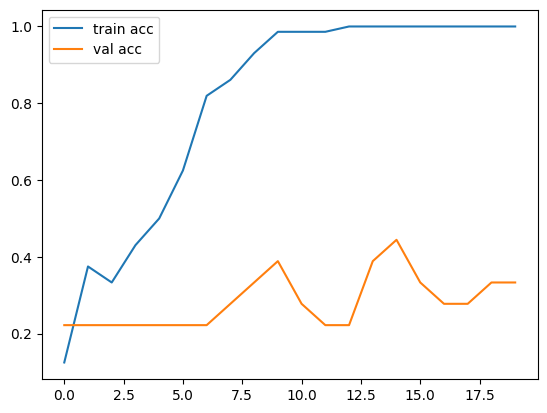

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

Visualizes training vs validation accuracy.
Helps detect overfitting or underfitting.